In [53]:
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd




In [54]:
final_metrics = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/comparison_NM_SC_GB.tsv', sep = '\t', header=0)

In [55]:
all_times = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/runtime_data.tsv', sep = '\t', header=0)

In [56]:
auc = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/auc_benchmark.csv', header=0, sep = ';')
auc

,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,NetMap_noD,0.60,0.64,0.74
4,NetMap_noD(Abs),0.54,0.61,0.73
5,NetMap_D,0.56,0.63,0.42
6,NetMap_D(Abs),0.51,0.62,0.42


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
auc

# Reshape wide -> long: one row per (Method, Case, AUC)


,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,NetMap_noD,0.60,0.64,0.74
4,NetMap_noD(Abs),0.54,0.61,0.73
5,NetMap_D,0.56,0.63,0.42
6,NetMap_D(Abs),0.51,0.62,0.42


In [58]:
auc = auc[auc.Method.isin(['LINGER', 'scPRINT', 'GRNBoost2', 'NetMap_noD'])].copy()
auc["Method"] = auc["Method"].replace("NetMap_noD", "NetMap")
auc_long = auc.melt(id_vars="Method", var_name="Case", value_name="AUC")
auc

,Method,Case 1,Case 2,Case 3
0,LINGER,0.76,0.71,0.70
1,scPRINT,NaN,0.56,0.53
2,GRNBoost2,0.56,0.51,0.58
3,NetMap,0.60,0.64,0.74


In [59]:
final_metrics["algorithm"] = final_metrics["algorithm"].replace({
    "netmap": "NetMap",
    "scgenerai": "scGeneRAI",
    "grnboost2": "GRNBoost2",
})

In [60]:
all_times["algorithm"] = all_times["root_config"].replace({
    "netmap": "NetMap",
    "scgenerai": "scGeneRAI",
    "grnboost2": "GRNBoost2",
})

In [61]:
# ---------------------------------------------------------------
algorithms = sorted(final_metrics["algorithm"].unique())
methods = sorted(auc["Method"].unique())

# Union of both label sets, so any name shared between the two
final_metrics["target_hr"] = final_metrics["target"].replace({
    "on_target": "On-target",
    "off_target": "Off-target",
})

In [62]:
final_metrics

,Unnamed: 0,index,n_top,net,avg_edges_recovered,mean_cell_count,gold_standard_edges,max_possible_edges,target,direction,...,precision,algorithm,config,dataset,tp,gs_count,pp,grn,n_clusters,target_hr
0,0,0,0.001,net_133_10773,4.0,128.500000,201.0,82369.0,on_target,forward,...,0.011902,NetMap,config_easy,net_133_10773_net_82_10152_net_72_10551,NaN,NaN,NaN,NaN,2,On-target
1,1,1,0.010,net_133_10773,9.0,307.000000,201.0,82369.0,on_target,forward,...,0.006636,NetMap,config_easy,net_133_10773_net_82_10152_net_72_10551,NaN,NaN,NaN,NaN,2,On-target
2,2,2,0.050,net_133_10773,26.0,347.692308,201.0,82369.0,on_target,forward,...,0.004362,NetMap,config_easy,net_133_10773_net_82_10152_net_72_10551,NaN,NaN,NaN,NaN,2,On-target
3,3,3,0.100,net_133_10773,49.0,277.469388,201.0,82369.0,on_target,forward,...,0.003282,NetMap,config_easy,net_133_10773_net_82_10152_net_72_10551,NaN,NaN,NaN,NaN,2,On-target
4,4,4,0.150,net_133_10773,64.0,297.890625,201.0,82369.0,on_target,forward,...,0.003070,NetMap,config_easy,net_133_10773_net_82_10152_net_72_10551,NaN,NaN,NaN,NaN,2,On-target
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41126,41126,4,0.200,2,NaN,NaN,NaN,NaN,on_target,NaN,...,NaN,GRNBoost2,config_three_noise,net_84_11226_net_172_10626_net_89_11634_net_76...,14.0,98.0,26225.0,2.0,3,On-target
41127,41127,5,0.250,2,NaN,NaN,NaN,NaN,on_target,NaN,...,NaN,GRNBoost2,config_three_noise,net_84_11226_net_172_10626_net_89_11634_net_76...,19.0,98.0,32781.0,2.0,3,On-target
41128,41128,6,0.500,2,NaN,NaN,NaN,NaN,on_target,NaN,...,NaN,GRNBoost2,config_three_noise,net_84_11226_net_172_10626_net_89_11634_net_76...,26.0,98.0,43967.0,2.0,3,On-target
41129,41129,7,0.750,2,NaN,NaN,NaN,NaN,on_target,NaN,...,NaN,GRNBoost2,config_three_noise,net_84_11226_net_172_10626_net_89_11634_net_76...,26.0,98.0,43967.0,2.0,3,On-target


In [63]:
import string

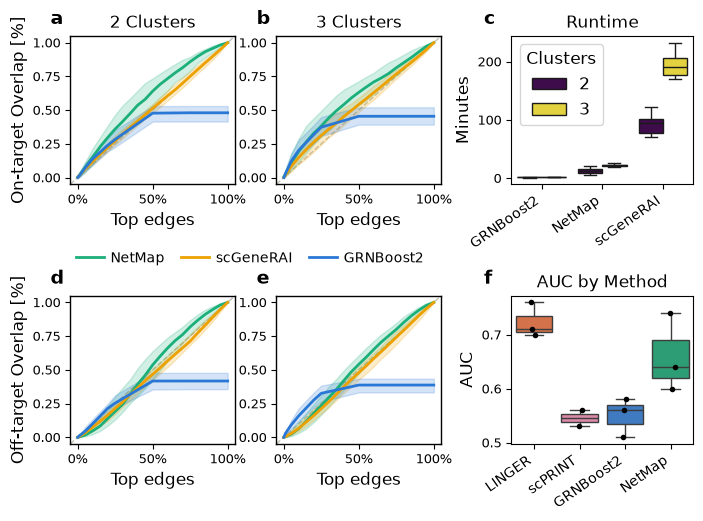

In [64]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# --- Global font sizing ---
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

CATEGORICAL_PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]

all_labels = sorted(set(algorithms) | set(methods))
palette = dict(zip(all_labels, CATEGORICAL_PALETTE * (len(all_labels) // len(CATEGORICAL_PALETTE) + 1)))

target_values = sorted(final_metrics["target_hr"].unique())
assert len(target_values) == 2, "Expected exactly 2 target values"
OFF_TARGET_VALUE = target_values[0]
ON_TARGET_VALUE = target_values[1]

n_clusters_values = [2, 3]

fig = plt.figure(figsize=(7, 5.3))

# ---------------------------------------------------------------
# Two separate GridSpecs sharing the figure:
#   gs_left  -> columns a/b (d/e), tight wspace between them
#   gs_right -> column c (f), pushed right with an extra gap
# ---------------------------------------------------------------
GAP = 0.1  # extra horizontal gap between column 2 and 3, tune as needed

gs_left = gridspec.GridSpec(2, 2, figure=fig, left=0.09, right=0.62, wspace=0.25, hspace=0.75)
gs_right = gridspec.GridSpec(2, 1, figure=fig, left=0.62 + GAP, right=0.98, hspace=0.75)

# ---------------------------------------------------------------
# Line panels: rows = on/off target, columns = n_clusters
# ---------------------------------------------------------------
row_specs = [
    ("On-target", ON_TARGET_VALUE, 0),
    ("Off-target", OFF_TARGET_VALUE, 1),
]
panel_labels = {(0, 0): 'a', (0, 1): 'b', (1, 0): 'd', (1, 1): 'e'}

line_axes = {}
first_line_ax = None

for row_name, target_val, row in row_specs:
    for col, n_clusters in enumerate(n_clusters_values):
        ax = fig.add_subplot(gs_left[row, col])
        line_axes[(row, col)] = ax
        if first_line_ax is None:
            first_line_ax = ax

        sub = final_metrics[
            (final_metrics["n_clusters"] == n_clusters)
            & (final_metrics["target_hr"] == target_val)
        ]

        sns.lineplot(
            data=sub,
            x="n_top",
            y="percentage_overlap",
            hue="algorithm",
            palette=palette,
            linewidth=2,
            markersize=6,
            estimator="median",
            errorbar=("pi", 50),
            ax=ax,
            legend=(ax is first_line_ax),
        )

        if row == 0:
            ax.set_title(f"{n_clusters} Clusters", fontsize=12)

        ax.set_xlabel("Top edges", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{row_name} Overlap [%]", fontsize=12)
        else:
            ax.set_ylabel("")
        ax.grid(False)
        sns.despine(ax=ax, left=False, bottom=False)

        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        lo, hi = xlim
        ax.plot([lo, hi], [lo, hi], color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

        ax.text(
            -0.12, 1.18, panel_labels[(row, col)],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top',
            ha='left',
        )

# ---------------------------------------------------------------
# Shared Algorithm legend: single horizontal row, no frame,
# right-bound, placed between row 0 (a/b) and row 1 (d/e).
# <-- TUNE legend_y if it overlaps the row above/below
# ---------------------------------------------------------------
handles, labels = first_line_ax.get_legend_handles_labels()
first_line_ax.get_legend().remove()

legend_y = 0.46  # figure-fraction y-coordinate; adjust to sit cleanly between rows
fig.legend(
    handles, labels,
    title=None,
    loc="center left",
    bbox_to_anchor=(0.08, legend_y),
    ncol=len(labels),
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    columnspacing=1.2,
    handletextpad=0.5,
)

# ---------------------------------------------------------------
# Panel c: runtime boxplot (top-right, own GridSpec)
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs_right[0, 0])
sns.boxplot(
    data=all_times[all_times.n_clusters.isin([2, 3])],
    x="algorithm",
    y="runtime_minutes",
    hue="n_clusters",
    palette="viridis",
    showfliers=False,
    ax=ax3,
)
ax3.set_title("Runtime", fontsize=12)
ax3.set_ylabel("Minutes", fontsize=12)
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=35, labelsize=10)
for label in ax3.get_xticklabels():
    label.set_ha("right")
ax3.legend(title="Clusters", fontsize=12, title_fontsize=12)
ax3.text(
    -0.15, 1.18, 'c',
    transform=ax3.transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left',
)

# ---------------------------------------------------------------
# Panel f: AUC boxplot by Method (bottom-right, own GridSpec)
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs_right[1, 0])
sns.boxplot(
    data=auc_long,
    x="Method",
    y="AUC",
    hue="Method",
    showfliers=False,
    ax=ax4,
    palette=palette,
)
sns.stripplot(
    data=auc_long,
    x="Method",
    y="AUC",
    color="black",
    size=4,
    jitter=True,
    ax=ax4,
)
ax4.set_xlabel("")
ax4.set_ylabel("AUC", fontsize=12)
ax4.set_title("AUC by Method", fontsize=12)
ax4.tick_params(axis="x", rotation=35, labelsize=10)
for label in ax4.get_xticklabels():
    label.set_ha("right")
ax4.text(
    -0.15, 1.18, 'f',
    transform=ax4.transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left',
)

fig.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/figure2.pdf',
    dpi=200, bbox_inches="tight"
)
plt.show()


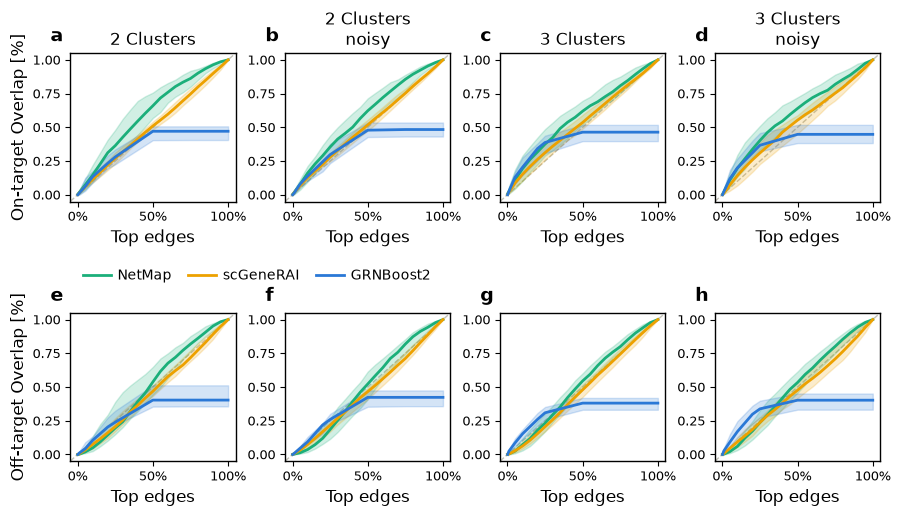

In [65]:
import string
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

# --- Global font sizing ---
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

CATEGORICAL_PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
]

def recode_number_of_datasets(config_item):
    if config_item == 'config_easy':
        return '2 Clusters'
    if config_item == 'config_noise':
        return '2 Clusters\nnoisy'
    if config_item == 'config_three':
        return '3 Clusters'
    if config_item == 'config_three_noise':
        return '3 Clusters\nnoisy'
    if config_item == 'config_five':
        return 5
    if config_item == 'config_ten':
        return 10


final_metrics['config'] = final_metrics['config'].apply(recode_number_of_datasets)

all_labels = sorted(set(algorithms) | set(methods))
palette = dict(zip(all_labels, CATEGORICAL_PALETTE * (len(all_labels) // len(CATEGORICAL_PALETTE) + 1)))

target_values = sorted(final_metrics["target_hr"].unique())
assert len(target_values) == 2, "Expected exactly 2 target values"
OFF_TARGET_VALUE = target_values[0]
ON_TARGET_VALUE = target_values[1]

config_values = sorted(final_metrics["config"].unique())
assert len(config_values) == 4, "Expected exactly 4 config values"
n_config_cols = len(config_values)

fig = plt.figure(figsize=(9, 5.3))

# ---------------------------------------------------------------
# Single GridSpec: 4 config columns x 2 target rows
# ---------------------------------------------------------------
gs_left = gridspec.GridSpec(2, n_config_cols, figure=fig, left=0.08, right=0.98, wspace=0.3, hspace=0.75)

# ---------------------------------------------------------------
# Line panels: rows = on/off target, columns = config
# ---------------------------------------------------------------
row_specs = [
    ("On-target", ON_TARGET_VALUE, 0),
    ("Off-target", OFF_TARGET_VALUE, 1),
]
letters = iter(string.ascii_lowercase)
panel_labels = {(row, col): next(letters) for row in range(2) for col in range(n_config_cols)}

line_axes = {}
first_line_ax = None

for row_name, target_val, row in row_specs:
    for col, config_val in enumerate(config_values):
        ax = fig.add_subplot(gs_left[row, col])
        line_axes[(row, col)] = ax
        if first_line_ax is None:
            first_line_ax = ax

        sub = final_metrics[
            (final_metrics["config"] == config_val)
            & (final_metrics["target_hr"] == target_val)
        ]

        sns.lineplot(
            data=sub,
            x="n_top",
            y="percentage_overlap",
            hue="algorithm",
            palette=palette,
            linewidth=2,
            markersize=6,
            estimator="median",
            errorbar=("pi", 50),
            ax=ax,
            legend=(ax is first_line_ax),
        )

        if row == 0:
            ax.set_title(f"{config_val}", fontsize=12)

        ax.set_xlabel("Top edges", fontsize=12)
        if col == 0:
            ax.set_ylabel(f"{row_name} Overlap [%]", fontsize=12)
        else:
            ax.set_ylabel("")
        ax.grid(False)
        sns.despine(ax=ax, left=False, bottom=False)

        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        lo, hi = xlim
        ax.plot([lo, hi], [lo, hi], color="#c3c2b7", linestyle="--", linewidth=1, zorder=0)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

        ax.text(
            -0.12, 1.18, panel_labels[(row, col)],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top',
            ha='left',
        )

# ---------------------------------------------------------------
# Shared Algorithm legend: single horizontal row, no frame,
# placed between row 0 and row 1.
# <-- TUNE legend_y if it overlaps the row above/below
# ---------------------------------------------------------------
handles, labels = first_line_ax.get_legend_handles_labels()
first_line_ax.get_legend().remove()

legend_y = 0.46  # figure-fraction y-coordinate; adjust to sit cleanly between rows
fig.legend(
    handles, labels,
    title=None,
    loc="center left",
    bbox_to_anchor=(0.08, legend_y),
    ncol=len(labels),
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    columnspacing=1.2,
    handletextpad=0.5,
)

fig.savefig(
    '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/figure2_sup.pdf',
    dpi=200, bbox_inches="tight"
)
plt.show()
